Procedural options
1. filter (gauss or savgol) the full trace -> take median across all time
2. take median per trial -> filter (savgol) -> median across trials
3. filter (gauss or savgol) the full trace -> take median per trial -> take median across trials

In [ ]:
%load_ext autoreload
from JR_test_scripts.escape.functions.escape_utils import load, load_homing, firing_by_bin_median_pandas, firing_by_bin_median_np, firing_by_bin_median_numba, firing_by_bin_median_ss
from JR_test_scripts.escape.functions.escape_data_loading_funcs import extract_homing_and_escape_periods
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from scipy.stats import mstats

%matplotlib inline

In [2]:
from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip4_21mar
exp = JAL6_flip4_21mar

%autoreload 2
comp = 'escape'
# load data
session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
ons, offs, homie = load_homing(session, len(behave))

2025-02-17 08:23:47.840 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


In [28]:
"""Compare median methods for speed
Spoiler: numba wins by a LOT"""
%autoreload 2
var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, 
                                                                                 frame_by_cluster_matrix, 
                                                                                 behave, 
                                                                                 y_pos, x_pos, 
                                                                                 bar, 
                                                                                 barflip, 
                                                                                 comp, 
                                                                                 ons, offs, 
                                                                                 no_stationary = False, 
                                                                                 return_escape = True,
                                                                                 zscore = False)

mat_by_cond = []
mat_pd_cond = []
mat_num_cond = []
np_time = []
pd_time = []
numba_time = []
ss_time = []
# iterate through conditions
for i in np.unique(cond):
    # start by condition
    cond_start = [x for x in h_start if cond[x] == i]
    cond_start.append(np.sum(cond == i))
    # initialize variable, neurons x trials x bins
    bins = int(np.amax(var)+1)
    mat_np = np.full((np.shape(escape_matrix)[0],len(cond_start),bins), np.nan)
    mat_pd = np.full((np.shape(escape_matrix)[0],len(cond_start),bins), np.nan)
    mat_num = np.full((np.shape(escape_matrix)[0],len(cond_start),bins), np.nan)
    mat_ss = np.full((np.shape(escape_matrix)[0],len(cond_start),bins), np.nan)
    # iterate through neurons
    for j, n in enumerate(escape_matrix):
        # iterate through trials, pull out firing by bin
        for tr, _ in enumerate(cond_start[:-1]):
            neur = n[cond_start[tr]:cond_start[tr+1]]
            v = var[cond_start[tr]:cond_start[tr+1]]
            import time
            t1 = time.time()
            mat_np[j, tr,:] = firing_by_bin_median_np(v.astype(int), neur, bins, remove_empty = False)
            t2 = time.time()
            np_time.append(t2-t1)
            mat_pd[j, tr,:] = firing_by_bin_median_pandas(v.astype(int), neur, bins, remove_empty = False)
            t3 = time.time()
            pd_time.append(t3-t2)
            mat_num[j, tr,:] = firing_by_bin_median_numba(v.astype(int), neur, bins, remove_empty = False)
            t4 = time.time()
            numba_time.append(t4-t3)
            mat_ss[j, tr,:] = firing_by_bin_median_ss(v.astype(int), neur, bins, remove_empty = False)
            t5 = time.time()
            ss_time.append(t5-t4)
    mat_by_cond.append(mat_np)
    mat_pd_cond.append(mat_pd)
    mat_num_cond.append(mat_num)
print('numpy time: ' + str(np.sum(np_time)))
print('pandas time: ' + str(np.sum(pd_time)))
print('numba time: ' + str(np.sum(numba_time)))
print('ss time: ' + str(np.sum(ss_time)))

numpy time: 141.02047181129456
pandas time: 41.530887603759766
numba time: 4.34249210357666
ss time: 146.2069365978241


In [ ]:
""""Plot all methods to confirm that the results actually look the same with all methods!"""

fig, axs = plt.subplots(1,3)
neuron = 17
c = 0
axs[0].imshow(mat_by_cond[c][neuron,:,:], cmap="gray_r", aspect="auto", interpolation = "none")
axs[1].imshow(mat_pd_cond[c][neuron,:,:], cmap="gray_r", aspect="auto", interpolation = "none")
axs[2].imshow(mat_num_cond[c][neuron,:,:], cmap="gray_r", aspect="auto", interpolation = "none")

compare median by trial or overall median!

In [3]:
"""Filter (gauss or savgol) the full trace -> take median across all time"""
def tuning_method1(frame_by_cluster_matrix, session, behave, y_pos, x_pos, bar, barflip, comp, ons, offs):
    fcm = gaussian_filter1d(frame_by_cluster_matrix, 2, axis = 0)
    # step 2: extract homie periods
    var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, 
                                                                                    fcm, 
                                                                                    behave, 
                                                                                    y_pos, x_pos, 
                                                                                    bar, 
                                                                                    barflip, 
                                                                                    comp, 
                                                                                    ons, offs, 
                                                                                    no_stationary = False, 
                                                                                    return_escape = True,
                                                                                    zscore = False)
    # step 3: compute firing by bin across all time
    nbins = int(np.amax(var)+1)
    tuning_by_cond = []
    for c in np.unique(cond):
        tuning_matrix = np.full((np.shape(escape_matrix)[0],nbins), np.nan) # neurons x bins
        neur = escape_matrix[:,cond == c]
        v = var[cond == c]
        for i, n in enumerate(neur):
            tuning_matrix[i,:] = firing_by_bin_median_numba(v.astype(int), n, nbins, remove_empty = False)
        tuning_by_cond.append(tuning_matrix)
    return tuning_by_cond

In [4]:
"""take median per trial -> filter (savgol) -> median across trials"""
def tuning_method2(frame_by_cluster_matrix, session, behave, y_pos, x_pos, bar, barflip, comp, ons, offs):
    # step 1: extract homie periods
    var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, 
                                                                                 frame_by_cluster_matrix, 
                                                                                 behave, 
                                                                                 y_pos, x_pos, 
                                                                                 bar, 
                                                                                 barflip, 
                                                                                 comp, 
                                                                                 ons, offs, 
                                                                                 no_stationary = False, 
                                                                                 return_escape = True,
                                                                                 zscore = False)
    # step 2: compute firing per bin per trial
    mat_num_cond = []
    tuning_by_cond = []
    # iterate through conditions
    for i in np.unique(cond):
        # start by condition
        cond_start = [x for x in h_start if cond[x] == i]
        cond_start.append(np.sum(cond == i))
        # initialize variable, neurons x trials x bins
        bins = int(np.amax(var)+1)
        mat_num = np.full((np.shape(escape_matrix)[0],len(cond_start),bins), np.nan)
        filt_shift = np.full((np.shape(escape_matrix)[0],bins), np.nan)
        # iterate through neurons
        for j, n in enumerate(escape_matrix):
            # iterate through trials, pull out firing by bin
            for tr, _ in enumerate(cond_start[:-1]):
                neur = n[cond_start[tr]:cond_start[tr+1]]
                v = var[cond_start[tr]:cond_start[tr+1]]
                mat_num[j, tr,:] = firing_by_bin_median_numba(v.astype(int), neur, bins, remove_empty = False)
            
            # step 3: filter
            matrix = mat_num[j, :, :]
            all_nan_rows = np.all(np.isnan(matrix), axis=1)
            matrix = matrix[~all_nan_rows,:]
            smooth_test = np.full_like(matrix, np.nan)
            # iterate over trials and smooth them
            for sidx, sxm in enumerate(matrix):
                this_line = np.full_like(sxm, np.nan)
                where_nan = np.isnan(sxm)
                # savgol
                this_line[~where_nan] = savgol_filter(sxm[~where_nan], window_length=11, polyorder=3)
                smooth_test[sidx,:] = this_line
            
            # step 4: take median across trials
            all_nan_cols = np.all(np.isnan(smooth_test), axis=0)
            smoothed_firing_rates = np.full(len(all_nan_cols), np.nan)
            smoothed_firing_rates[~all_nan_cols] = np.nanmedian(smooth_test[:,~all_nan_cols], axis = 0)
            filt_shift[j, :] = smoothed_firing_rates
            
        # dump them in big lists    
        tuning_by_cond.append(filt_shift)
        mat_num_cond.append(mat_num)
    return tuning_by_cond, mat_num_cond

In [5]:
"""filter (gauss or savgol) the full trace -> take median per trial -> take median across trials"""
def tuning_method3(frame_by_cluster_matrix, session, behave, y_pos, x_pos, bar, barflip, comp, ons, offs):
    # step 1: filter the full trace
    frame_by_cluster_matrix = gaussian_filter1d(frame_by_cluster_matrix, 2, axis = 0)
    # step 2: extract homie periods
    var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, 
                                                                                 frame_by_cluster_matrix, 
                                                                                 behave, 
                                                                                 y_pos, x_pos, 
                                                                                 bar, 
                                                                                 barflip, 
                                                                                 comp, 
                                                                                 ons, offs, 
                                                                                 no_stationary = False, 
                                                                                 return_escape = True,
                                                                                 zscore = False)
    # step 3: compute firing per bin per trial
    mat_num_cond = []
    tuning_by_cond = []
    # iterate through conditions
    for i in np.unique(cond):
        # start by condition
        cond_start = [x for x in h_start if cond[x] == i]
        cond_start.append(np.sum(cond == i))
        # initialize variable, neurons x trials x bins
        bins = int(np.amax(var)+1)
        mat_num = np.full((np.shape(escape_matrix)[0],len(cond_start),bins), np.nan)
        filt_shift = np.full((np.shape(escape_matrix)[0],bins), np.nan)
        # iterate through neurons
        for j, n in enumerate(escape_matrix):
            # iterate through trials, pull out firing by bin
            for tr, _ in enumerate(cond_start[:-1]):
                neur = n[cond_start[tr]:cond_start[tr+1]]
                v = var[cond_start[tr]:cond_start[tr+1]]
                mat_num[j, tr,:] = firing_by_bin_median_numba(v.astype(int), neur, bins, remove_empty = False)
            
            # step 4: take median across trials
            mat = mat_num[j, :,:]
            all_nan_cols = np.all(np.isnan(mat), axis=0)
            smoothed_firing_rates = np.full(len(all_nan_cols), np.nan)
            smoothed_firing_rates[~all_nan_cols] = np.nanmedian(mat[:,~all_nan_cols], axis = 0)
            filt_shift[j, :] = smoothed_firing_rates
            
        # dump them in big lists    
        tuning_by_cond.append(filt_shift)
        mat_num_cond.append(mat_num)
    return tuning_by_cond, mat_num_cond

In [6]:
"""filter (gauss or savgol) the full trace -> take median per trial -> take avg of 25th and 75ht perc across trials"""
def tuning_method4(frame_by_cluster_matrix, session, behave, y_pos, x_pos, bar, barflip, comp, ons, offs):
    # step 1: filter the full trace
    frame_by_cluster_matrix = gaussian_filter1d(frame_by_cluster_matrix, 2, axis = 0)
    # step 2: extract homie periods
    var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, 
                                                                                 frame_by_cluster_matrix, 
                                                                                 behave, 
                                                                                 y_pos, x_pos, 
                                                                                 bar, 
                                                                                 barflip, 
                                                                                 comp, 
                                                                                 ons, offs, 
                                                                                 no_stationary = False, 
                                                                                 return_escape = True,
                                                                                 zscore = False)
    # step 3: compute firing per bin per trial
    mat_num_cond = []
    tuning_by_cond = []
    # iterate through conditions
    for i in np.unique(cond):
        # start by condition
        cond_start = [x for x in h_start if cond[x] == i]
        cond_start.append(np.sum(cond == i))
        # initialize variable, neurons x trials x bins
        bins = int(np.amax(var)+1)
        mat_num = np.full((np.shape(escape_matrix)[0],len(cond_start),bins), np.nan)
        filt_shift = np.full((np.shape(escape_matrix)[0],bins), np.nan)
        # iterate through neurons
        for j, n in enumerate(escape_matrix):
            # iterate through trials, pull out firing by bin
            for tr, _ in enumerate(cond_start[:-1]):
                neur = n[cond_start[tr]:cond_start[tr+1]]
                v = var[cond_start[tr]:cond_start[tr+1]]
                mat_num[j, tr,:] = firing_by_bin_median_numba(v.astype(int), neur, bins, remove_empty = False)
            
            # step 4: take median across trials
            mat = mat_num[j, :,:]
            all_nan_cols = np.all(np.isnan(mat), axis=0)
            smoothed_firing_rates = np.full(len(all_nan_cols), np.nan)
            Fr_25th = np.nanpercentile(mat[:,~all_nan_cols], 40, axis = 0)
            Fr_75th = np.nanpercentile(mat[:,~all_nan_cols], 60, axis = 0)
            smoothed_firing_rates[~all_nan_cols] = np.nanmean(np.vstack((Fr_25th,Fr_75th)), axis = 0)
            filt_shift[j, :] = smoothed_firing_rates
            
        # dump them in big lists    
        tuning_by_cond.append(filt_shift)
        mat_num_cond.append(mat_num)
    return tuning_by_cond, mat_num_cond

In [11]:
"""filter (gauss or savgol) the full trace -> take median per trial -> winsorized mean (15th and 85th percentile) across trials"""
def nan_winsorized_mean_2d(data, limits=(0.1, 0.1), axis=0):
    """
    Compute the winsorized mean along a given axis while ignoring NaNs.

    Parameters:
        data (ndarray): 2D input array, may contain NaNs.
        limits (tuple): Fraction to trim from (low, high) ends.
        axis (int): Axis along which to compute the winsorized mean.

    Returns:
        ndarray: Winsorized mean along the specified axis.
    """
    data = np.asarray(data)
    
    # Apply Winsorization along the specified axis while ignoring NaNs
    def winsorize_nan_safe(arr):
        non_nan_arr = arr[~np.isnan(arr)]  # Remove NaNs
        if len(non_nan_arr) == 0:
            return np.nan  # Return NaN if all values were NaN
        return np.mean(mstats.winsorize(non_nan_arr, limits=limits))  # Winsorized mean
    
    return np.apply_along_axis(winsorize_nan_safe, axis, data)

def tuning_method5(frame_by_cluster_matrix, session, behave, y_pos, x_pos, bar, barflip, comp, ons, offs):
    # step 1: filter the full trace
    frame_by_cluster_matrix = gaussian_filter1d(frame_by_cluster_matrix, 2, axis = 0)
    # step 2: extract homie periods
    var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, 
                                                                                 frame_by_cluster_matrix, 
                                                                                 behave, 
                                                                                 y_pos, x_pos, 
                                                                                 bar, 
                                                                                 barflip, 
                                                                                 comp, 
                                                                                 ons, offs, 
                                                                                 no_stationary = False, 
                                                                                 return_escape = True,
                                                                                 zscore = False)

    # step 3: compute firing per bin per trial
    mat_num_cond = []
    tuning_by_cond_new = []
    # iterate through conditions
    for i in np.unique(cond):
        # start by condition
        cond_start = [x for x in h_start if cond[x] == i]
        cond_start.append(np.sum(cond == i))
        # initialize variable, neurons x trials x bins
        bins = int(np.amax(var)+1)
        mat_num = np.full((np.shape(escape_matrix)[0],len(cond_start),bins), np.nan)
        filt_shift = np.full((np.shape(escape_matrix)[0],bins), np.nan)
        # iterate through neurons
        for j, n in enumerate(escape_matrix):
            # iterate through trials, pull out firing by bin
            for tr, _ in enumerate(cond_start[:-1]):
                neur = n[cond_start[tr]:cond_start[tr+1]]
                v = var[cond_start[tr]:cond_start[tr+1]]
                mat_num[j, tr,:] = firing_by_bin_median_numba(v.astype(int), neur, bins, remove_empty = False)
            
            # step 4: take median across trials
            mat = mat_num[j, :,:]
            all_nan_cols = np.all(np.isnan(mat), axis=0)
            smoothed_firing_rates = np.full(len(all_nan_cols), np.nan)
            winz = nan_winsorized_mean_2d(mat[:,~all_nan_cols], limits=(.15, .15), axis = 0)
            smoothed_firing_rates[~all_nan_cols] = winz
            filt_shift[j, :] = smoothed_firing_rates
            
        # dump them in big lists    
        tuning_by_cond_new.append(filt_shift)
        mat_num_cond.append(mat_num)

    return tuning_by_cond_new, mat_num_cond

Needed plots:
- for a given cell, in a given condition
- compare trial matrix method 2 and 3
- compare avg trace 1,2,3

In [70]:
"""Make a plot for each cell comparing the methods of calculating the median response"""
c_names = ['shelter_only', 'barrier', 'barrier_flipped']

for comp in ['escape', 'bird_dist_shelter']:
    tuning_by_cond1 = tuning_method1(frame_by_cluster_matrix, session, behave, y_pos, x_pos, bar, barflip, comp, ons, offs)
    tuning_by_cond2, mat_num_cond2 = tuning_method2(frame_by_cluster_matrix, session, behave, y_pos, x_pos, bar, barflip, comp, ons, offs)
    tuning_by_cond3, mat_num_cond3 = tuning_method3(frame_by_cluster_matrix, session, behave, y_pos, x_pos, bar, barflip, comp, ons, offs)
    tuning_by_cond4, mat_num_cond4 = tuning_method4(frame_by_cluster_matrix, session, behave, y_pos, x_pos, bar, barflip, comp, ons, offs)
    
    nickname = exp.nick_name + '_' + exp.experiment_date
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
    dump_path = "Z:/Jasmine_Laurence/summary_plots/tuning_curves/" + nickname + "/" + exp_nickname

    for neur in np.arange(tuning_by_cond1[0].shape[0]):
        fig, axs = plt.subplots(3,3, figsize = (12,12))

        # compute min/max for this neuron across all conditions
        neuron_data = np.concatenate([mat_num_cond2[c][neur,:,:] for c in range(3)] +
                                    [mat_num_cond3[c][neur,:,:] for c in range(3)])  # Flatten across conditions
        vmin, vmax = np.nanmin(neuron_data), np.nanmax(neuron_data)  # Ignore NaNs

        # compute min/max for the average also
        avg_data = np.concatenate([tuning_by_cond1[c][neur,:] for c in range(3)] + 
                                [tuning_by_cond2[c][neur,:] for c in range(3)] + 
                                [tuning_by_cond3[c][neur,:] for c in range(3)] + 
                                [tuning_by_cond4[c][neur,:] for c in range(3)])
        ylim = [np.nanmin(avg_data), np.nanmax(avg_data)]

        for c in [0,1,2]:
            axs[c,0].imshow(mat_num_cond2[c][neur,:,:], cmap="gray_r", vmin = vmin, vmax = vmax, aspect="auto", interpolation = "none")
            axs[c,0].set_ylabel(c_names[c] + ' trials')
            axs[c,0].set_title('2. Median then filter')
            axs[c,1].imshow(mat_num_cond3[c][neur,:,:], cmap="gray_r", vmin = vmin, vmax = vmax, aspect="auto", interpolation = "none")
            axs[c,1].set_title('3. Filter, then median')
            # compare the final trace from all three methods
            axs[c,2].plot(tuning_by_cond1[c][neur,:],'k',label = '1. across time')
            axs[c,2].plot(tuning_by_cond2[c][neur,:],'r',label = '2. Median then filter')
            axs[c,2].plot(tuning_by_cond3[c][neur,:],'g',label = '3. Filter, then median')
            axs[c,2].plot(tuning_by_cond4[c][neur,:],'b',label = '4. Filter, then 25th 75th perc avg')
            axs[c,2].set_ylim(ylim)
            axs[c,2].legend()
        plt.tight_layout()
        fig.savefig(dump_path + "/neuron" + str(neur) + "_median_compare.png")
        plt.close()

C:\Users\Jasmine\AppData\Local\Temp\ipykernel_23248\79351579.py:38: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axs[c,2].set_ylim(ylim)


In [12]:
"""Check out the plots comparing the methods for computing the tuning curve, especially median vs winsorized mean"""
c_names = ['shelter_only', 'barrier', 'barrier_flipped']
comp = 'escape'

# tuning_by_cond3, mat_num_cond3 = tuning_method3(frame_by_cluster_matrix, session, behave, y_pos, x_pos, bar, barflip, comp, ons, offs)
# tuning_by_cond4, mat_num_cond4 = tuning_method4(frame_by_cluster_matrix, session, behave, y_pos, x_pos, bar, barflip, comp, ons, offs)
tuning_by_cond_new, _ = tuning_method5(frame_by_cluster_matrix, session, behave, y_pos, x_pos, bar, barflip, comp, ons, offs)

nickname = exp.nick_name + '_' + exp.experiment_date
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
dump_path = "Z:/Jasmine_Laurence/summary_plots/tuning_curves/" + nickname + "/" + exp_nickname

for neur in np.arange(tuning_by_cond3[0].shape[0]):
    fig, axs = plt.subplots(3,2, figsize = (12,12))

    # compute min/max for this neuron across all conditions
    neuron_data = np.concatenate([mat_num_cond3[c][neur,:,:] for c in range(3)])  # Flatten across conditions
    vmin, vmax = np.nanmin(neuron_data), np.nanmax(neuron_data)  # Ignore NaNs

    # compute min/max for the average also
    avg_data = np.concatenate([tuning_by_cond3[c][neur,:] for c in range(3)] + 
                            [tuning_by_cond4[c][neur,:] for c in range(3)] + 
                            [tuning_by_cond_new[c][neur,:] for c in range(3)])
    ylim = [np.nanmin(avg_data), np.nanmax(avg_data)]

    for c in [0,1,2]:
        axs[c,0].imshow(mat_num_cond3[c][neur,:,:], cmap="gray_r", vmin = vmin, vmax = vmax, aspect="auto", interpolation = "none")
        axs[c,0].set_ylabel(c_names[c] + ' trials')
        axs[c,0].set_title('1. Filter, then median')
        # compare the final trace from all three methods
        axs[c,1].plot(tuning_by_cond3[c][neur,:],'g',label = '1. Filter, then median')
        axs[c,1].plot(tuning_by_cond4[c][neur,:],'b',label = '2. Filter, then 25th 75th perc avg')
        axs[c,1].plot(tuning_by_cond_new[c][neur,:],'k',label = '3. Winsorized mean')
        axs[c,1].set_ylabel('Firing rate')
        axs[c,1].set_ylim(ylim)
        axs[c,1].legend()
    plt.tight_layout()
    fig.savefig(dump_path + "/neuron" + str(neur) + "_median_compare_new.png")
    plt.close()

C:\Users\Jasmine\AppData\Local\Temp\ipykernel_2296\3190939986.py:35: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axs[c,1].set_ylim(ylim)


A method for computing reliability of response

In [105]:
def leave_one_out_reliability_timepoint(var, escape_matrix, cond, h_start, bins, n_cond, n_neur):
    """Computes a reliability score for each cell, at each time bin, using leave-one-out correlation across trials"""
    
    # Initialize output variables
    reliability = np.full((n_cond, n_neur, bins), np.nan)  # Now reliability is computed for each bin
    fr_full = np.zeros((n_cond, n_neur, bins))  # conditions x neurons x bins
    c = [len([x for x in h_start if cond[x] == i]) for i in range(n_cond)]
    mat_num_cond = np.full((n_cond, n_neur, max(c), bins), np.nan)  # conditions x neurons x trials x bins

    # Iterate through conditions
    for i in range(n_cond):
        i = int(i)
        # Start by condition
        cond_start = [x for x in h_start if cond[x] == i]
        cond_start.append(np.sum(cond == i))
        
        # Iterate through neurons
        for j, n in enumerate(escape_matrix):
            # Iterate through trials, pull out firing by bin
            for tr, _ in enumerate(cond_start[:-1]):
                neur = n[cond_start[tr]:cond_start[tr+1]]
                v = var[cond_start[tr]:cond_start[tr+1]]
                mat_num_cond[i, j, tr, :] = firing_by_bin_median_numba(v.astype(int), neur, bins, remove_empty=False)
            
            mat = mat_num_cond[i, j, :, :]  # trials x bins
            all_nan_cols = np.all(np.isnan(mat), axis=0)
            smoothed_firing_rates = np.full(bins, np.nan)
            if np.any(~all_nan_cols):  # Ensure at least one valid column exists
                smoothed_firing_rates[~all_nan_cols] = np.nanmedian(mat[:, ~all_nan_cols], axis=0)

            # Leave-one-out reliability per timepoint
            tr_corr_coeff = np.full((mat_num_cond.shape[2], bins), np.nan)  # trials x bins
            tr_rms = np.full((mat_num_cond.shape[2], bins), np.nan)

            if np.sum(smoothed_firing_rates) > 0:
                for tr in range(mat_num_cond.shape[2]):  # Loop over trials and leave one out
                    loo_mat = np.delete(mat, tr, axis=0)  # Remove one trial at a time
                    if loo_mat.shape[0] == 0:  # Prevent empty matrix issues
                        continue
                    
                    all_nan_cols = np.all(np.isnan(loo_mat), axis=0)
                    loo = np.full(bins, np.nan)
                    if np.any(~all_nan_cols):
                        loo[~all_nan_cols] = np.nanmedian(loo_mat[:, ~all_nan_cols], axis=0)
                    
                    # Correlation for each time bin
                    for b in range(bins):
                        if not np.isnan(loo[b]) and not np.isnan(mat[tr, b]):  # Avoid NaNs
                            if np.std(loo_mat[:, b]) > 0 and np.std(mat[:, b]) > 0:
                                if loo_mat.shape[0] > 1:  # Ensure we have at least 2 trials
                                    tr_corr_coeff[tr, b] = np.corrcoef(loo_mat[:, b], np.full(loo_mat.shape[0], mat[tr, b]))[0, 1]

                    tr_rms[tr, :] = np.sqrt(np.mean(mat[tr, :] ** 2))  # RMS for weighting
                
                # Average across trials to get reliability at each bin
                for b in range(bins):
                    id_nans = np.isnan(tr_corr_coeff[:, b]) | np.isnan(tr_rms[:, b])
                    if np.sum(~id_nans) > 1:  # Ensure at least 2 valid trials
                        reliability[i, j, b] = np.average(tr_corr_coeff[~id_nans, b], weights=tr_rms[~id_nans, b])

            # Store the firing rates
            fr_full[i, j, :] = smoothed_firing_rates

    return fr_full, mat_num_cond, reliability

c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\Jasmine\AppData\Local\Temp\ipykernel_23248\4166190772.py:6: RuntimeWarning: invalid value encountered in divide
  zscore = np.nanmean(mat, axis = 0)/np.nanstd(mat, axis = 0)


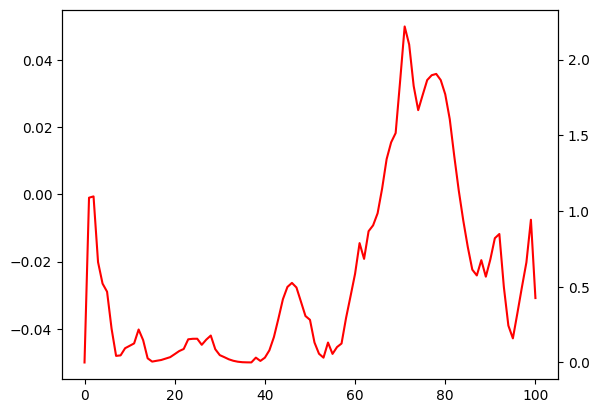

In [106]:
fr_full, mat_num_cond, reliability = leave_one_out_reliability_timepoint(var, escape_matrix, cond, h_start, bins, 3, escape_matrix.shape[0])

# step 4: take median across trials
i = 2
mat = mat_num_cond[i][j, :,:]
zscore = np.nanmean(mat, axis = 0)/np.nanstd(mat, axis = 0)
fig, axs = plt.subplots(1,1)
axs.plot(reliability[i,j,:])
axs2 = axs.twinx()
axs2.plot(np.nanmean(mat,axis =0), 'r')
# all_nan_cols = np.all(np.isnan(mat), axis=0)
# smoothed_firing_rates = np.full(len(all_nan_cols), np.nan)
# Fr_25th = np.nanpercentile(mat[:,~all_nan_cols], 40, axis = 0)
# Fr_75th = np.nanpercentile(mat[:,~all_nan_cols], 60, axis = 0)
# smoothed_firing_rates[~all_nan_cols] = np.nanmean(np.vstack((Fr_25th,Fr_75th)), axis = 0)
# filt_shift[j, :] = smoothed_firing_rates